In [1]:
import tensorflow as tf

print("TensorFlow sürümü:", tf.__version__)
print("GPU Var mı:", tf.config.list_physical_devices('GPU'))

TensorFlow sürümü: 2.20.0
GPU Var mı: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [2]:
!pip install -q kaggle

In [3]:
from google.colab import files
files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"yusufkocaolan","key":"9409ae4f3b80c6bf16880ba775816667"}'}

In [4]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [5]:
!kaggle datasets download -d emmarex/plantdisease

Dataset URL: https://www.kaggle.com/datasets/emmarex/plantdisease
License(s): unknown
100% 658M/658M [00:37<00:00, 18.4MB/s]



In [6]:
!unzip plantdisease.zip

Görüntülenen çıkış son 5000 satıra kısaltıldı.
  inflating: plantvillage/PlantVillage/Tomato__Tomato_YellowLeaf__Curl_Virus/08c033bd-fbc3-445a-88d1-1863070e52ce___YLCV_GCREC 2872.JPG  
  inflating: plantvillage/PlantVillage/Tomato__Tomato_YellowLeaf__Curl_Virus/08dd176c-e9d9-4746-92c3-fa8dc9074347___UF.GRC_YLCV_Lab 03057.JPG  
  inflating: plantvillage/PlantVillage/Tomato__Tomato_YellowLeaf__Curl_Virus/08f78a80-46f5-45a6-937c-4d05d61c08c2___UF.GRC_YLCV_Lab 01895.JPG  
  inflating: plantvillage/PlantVillage/Tomato__Tomato_YellowLeaf__Curl_Virus/0903aa95-6e8a-4abd-a003-126fcd9a5493___YLCV_GCREC 2806.JPG  
  inflating: plantvillage/PlantVillage/Tomato__Tomato_YellowLeaf__Curl_Virus/0911d416-d73d-4c2a-8e45-207a7ceb7c9a___YLCV_GCREC 2773.JPG  
  inflating: plantvillage/PlantVillage/Tomato__Tomato_YellowLeaf__Curl_Virus/09188838-cc89-4925-94c5-d9563c4cb4bf___UF.GRC_YLCV_Lab 02974.JPG  
  inflating: plantvillage/PlantVillage/Tomato__Tomato_YellowLeaf__Curl_Virus/0922e026-b563-438d-b9ed-747615

In [7]:
!ls

kaggle.json  plantdisease.zip  plantvillage  PlantVillage  sample_data


In [8]:
import os

dataset_path = "PlantVillage"

classes = os.listdir(dataset_path)

print("Toplam sınıf sayısı:", len(classes))
print(classes)

Toplam sınıf sayısı: 15
['Tomato_Bacterial_spot', 'Pepper__bell___Bacterial_spot', 'Tomato_Leaf_Mold', 'Pepper__bell___healthy', 'Tomato_Spider_mites_Two_spotted_spider_mite', 'Tomato__Target_Spot', 'Tomato_healthy', 'Tomato_Early_blight', 'Tomato__Tomato_YellowLeaf__Curl_Virus', 'Potato___healthy', 'Tomato_Septoria_leaf_spot', 'Tomato_Late_blight', 'Potato___Late_blight', 'Potato___Early_blight', 'Tomato__Tomato_mosaic_virus']


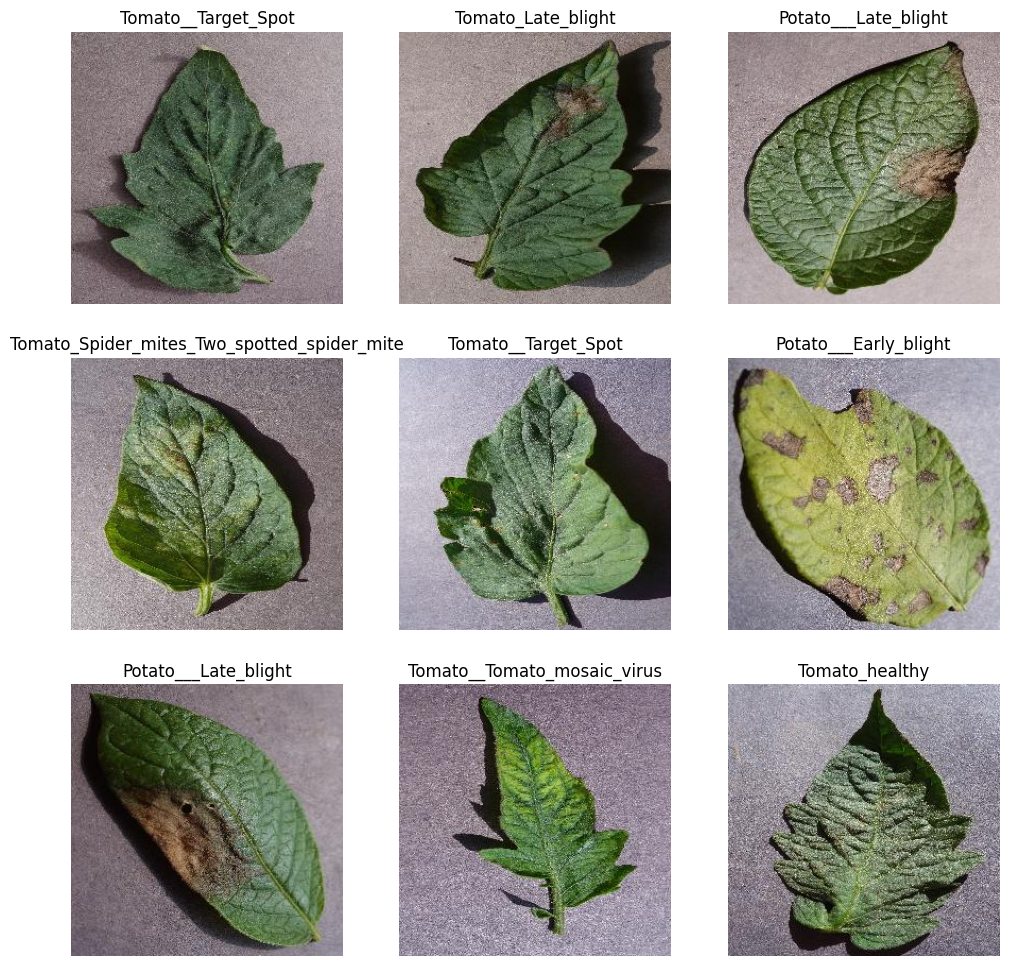

In [9]:
import matplotlib.pyplot as plt
from PIL import Image
import random

plt.figure(figsize=(12,12))

for i in range(9):
    class_name = random.choice(classes)
    image_name = random.choice(os.listdir(os.path.join(dataset_path, class_name)))

    image_path = os.path.join(dataset_path, class_name, image_name)

    img = Image.open(image_path)

    plt.subplot(3,3,i+1)
    plt.imshow(img)
    plt.title(class_name)
    plt.axis("off")

plt.show()

In [10]:
import tensorflow as tf

img_size = (224, 224)
batch_size = 32

train_data = tf.keras.preprocessing.image_dataset_from_directory(
    dataset_path,
    validation_split=0.2,
    subset="training",
    seed=42,
    image_size=img_size,
    batch_size=batch_size
)

val_data = tf.keras.preprocessing.image_dataset_from_directory(
    dataset_path,
    validation_split=0.2,
    subset="validation",
    seed=42,
    image_size=img_size,
    batch_size=batch_size
)

Found 20638 files belonging to 15 classes.
Using 16511 files for training.
Found 20638 files belonging to 15 classes.
Using 4127 files for validation.


In [11]:
class_names = train_data.class_names

print("Sınıf sayısı:", len(class_names))
print(class_names)

Sınıf sayısı: 15
['Pepper__bell___Bacterial_spot', 'Pepper__bell___healthy', 'Potato___Early_blight', 'Potato___Late_blight', 'Potato___healthy', 'Tomato_Bacterial_spot', 'Tomato_Early_blight', 'Tomato_Late_blight', 'Tomato_Leaf_Mold', 'Tomato_Septoria_leaf_spot', 'Tomato_Spider_mites_Two_spotted_spider_mite', 'Tomato__Target_Spot', 'Tomato__Tomato_YellowLeaf__Curl_Virus', 'Tomato__Tomato_mosaic_virus', 'Tomato_healthy']


In [12]:
from tensorflow.keras import layers, models

model = models.Sequential([

    layers.Rescaling(1./255, input_shape=(224,224,3)),

    # Block 1
    layers.Conv2D(32, (3,3), padding='same', activation='relu'),
    layers.BatchNormalization(),
    layers.Conv2D(32, (3,3), padding='same', activation='relu'),
    layers.MaxPooling2D(),
    layers.Dropout(0.2),

    # Block 2
    layers.Conv2D(64, (3,3), padding='same', activation='relu'),
    layers.BatchNormalization(),
    layers.Conv2D(64, (3,3), padding='same', activation='relu'),
    layers.MaxPooling2D(),
    layers.Dropout(0.25),

    # Block 3
    layers.Conv2D(128, (3,3), padding='same', activation='relu'),
    layers.BatchNormalization(),
    layers.Conv2D(128, (3,3), padding='same', activation='relu'),
    layers.MaxPooling2D(),
    layers.Dropout(0.3),

    # Block 4
    layers.Conv2D(256, (3,3), padding='same', activation='relu'),
    layers.BatchNormalization(),
    layers.GlobalAveragePooling2D(),

    # Dense
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.4),

    layers.Dense(len(class_names), activation='softmax')
])

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/preprocessing/data_layer.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)           │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 224, 224, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 112, 112, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 56, 56, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 28, 28, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 28, 28, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │        65,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 15)             │         3,855 │
└─────────────────────────────────┴────────────────────────┴─────────────

 Total params: 653,743 (2.49 MB)

 Trainable params: 652,783 (2.49 MB)

 Non-trainable params: 960 (3.75 KB)

In [13]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [14]:
history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=10
)

Epoch 1/10
516/516 ━━━━━━━━━━━━━━━━━━━━ 123s 193ms/step - accuracy: 0.6869 - loss: 0.9672 - val_accuracy: 0.3395 - val_loss: 2.9021
Epoch 2/10
516/516 ━━━━━━━━━━━━━━━━━━━━ 76s 147ms/step - accuracy: 0.8248 - loss: 0.5275 - val_accuracy: 0.4299 - val_loss: 2.3799
Epoch 3/10
516/516 ━━━━━━━━━━━━━━━━━━━━ 77s 149ms/step - accuracy: 0.8675 - loss: 0.3948 - val_accuracy: 0.4124 - val_loss: 3.8531
Epoch 4/10
516/516 ━━━━━━━━━━━━━━━━━━━━ 78s 151ms/step - accuracy: 0.8986 - loss: 0.3091 - val_accuracy: 0.8883 - val_loss: 0.3282
Epoch 5/10
516/516 ━━━━━━━━━━━━━━━━━━━━ 78s 151ms/step - accuracy: 0.9144 - loss: 0.2560 - val_accuracy: 0.6404 - val_loss: 1.3919
Epoch 6/10
516/516 ━━━━━━━━━━━━━━━━━━━━ 83s 162ms/step - accuracy: 0.9285 - loss: 0.2181 - val_accuracy: 0.5677 - val_loss: 1.7461
Epoch 7/10
516/516 ━━━━━━━━━━━━━━━━━━━━ 77s 150ms/step - accuracy: 0.9343 - loss: 0.1934 - val_accuracy: 0.8289 - val_loss: 0.5793
Epoch 8/10
516/516 ━━━━━━━━━━━━━━━━━━━━ 79s 153ms/step - accuracy: 0.9452 - loss: 

In [15]:
test_loss, test_acc = model.evaluate(val_data)

print("Test Accuracy:", test_acc)
print("Test Loss:", test_loss)

129/129 ━━━━━━━━━━━━━━━━━━━━ 5s 37ms/step - accuracy: 0.7805 - loss: 0.8690
Test Accuracy: 0.780470073223114
Test Loss: 0.8690467476844788


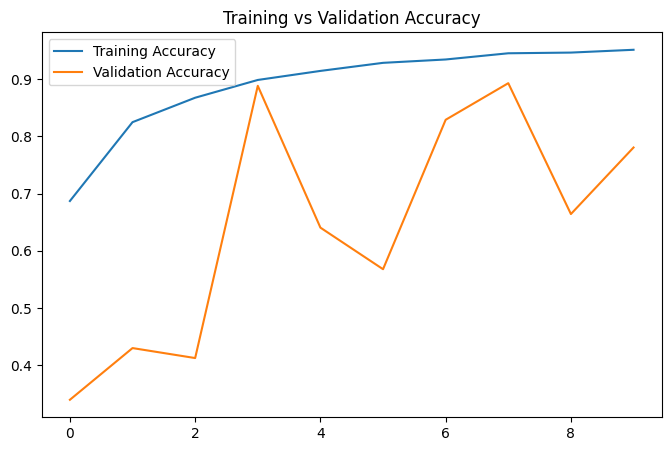

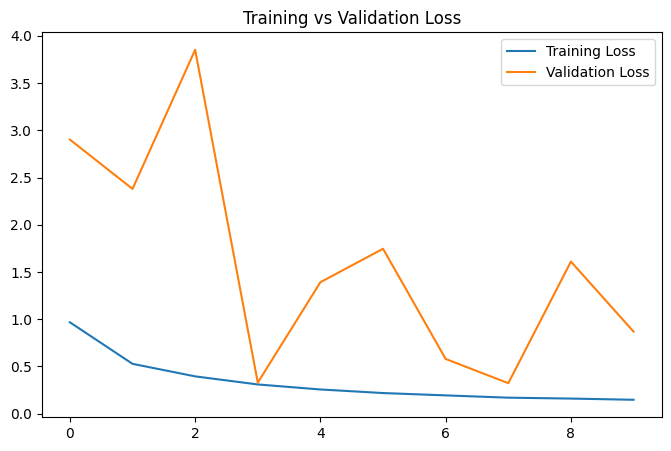

In [16]:
import matplotlib.pyplot as plt

acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

loss = history.history['loss']
val_loss = history.history['val_loss']

epochs_range = range(10)

# Accuracy Grafiği
plt.figure(figsize=(8,5))
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.legend()
plt.title('Training vs Validation Accuracy')
plt.show()

# Loss Grafiği
plt.figure(figsize=(8,5))
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.legend()
plt.title('Training vs Validation Loss')
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 738ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 126ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 118ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 102ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 112ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 110ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 114ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 115ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 108ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 96ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 99ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 95ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 94ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 94ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 96ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 88ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step
1/1

<Figure size 1200x1200 with 0 Axes>

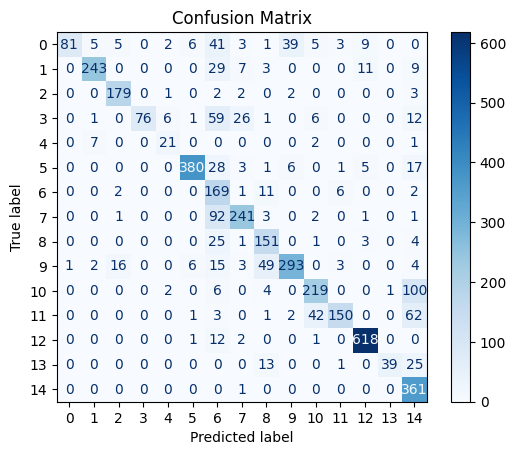

In [17]:
import numpy as np
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

y_true = []
y_pred = []

for images, labels in val_data:
    predictions = model.predict(images)
    predicted_labels = np.argmax(predictions, axis=1)

    y_true.extend(labels.numpy())
    y_pred.extend(predicted_labels)

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(12,12))
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap='Blues')
plt.title("Confusion Matrix")
plt.show()

In [18]:
from sklearn.metrics import classification_report

report = classification_report(
    y_true,
    y_pred,
    target_names=class_names
)

print(report)

                                             precision    recall  f1-score   support

              Pepper__bell___Bacterial_spot       0.99      0.41      0.57       200
                     Pepper__bell___healthy       0.94      0.80      0.87       302
                      Potato___Early_blight       0.88      0.95      0.91       189
                       Potato___Late_blight       1.00      0.40      0.58       188
                           Potato___healthy       0.66      0.68      0.67        31
                      Tomato_Bacterial_spot       0.96      0.86      0.91       441
                        Tomato_Early_blight       0.35      0.88      0.50       191
                         Tomato_Late_blight       0.83      0.71      0.76       341
                           Tomato_Leaf_Mold       0.63      0.82      0.71       185
                  Tomato_Septoria_leaf_spot       0.86      0.75      0.80       392
Tomato_Spider_mites_Two_spotted_spider_mite       0.79      0.66

In [20]:
model.save("AgroLeafNet_model.keras")

In [21]:
from sklearn.metrics import precision_score, recall_score, f1_score

train_acc = history.history['accuracy'][-1]
train_loss = history.history['loss'][-1]

test_loss, test_acc = model.evaluate(val_data)

precision = precision_score(y_true, y_pred, average='macro')
recall = recall_score(y_true, y_pred, average='macro')
f1 = f1_score(y_true, y_pred, average='macro')

print("=== PERFORMANS METRİKLERİ ===")
print("Eğitim Accuracy:", train_acc)
print("Eğitim Loss:", train_loss)
print("Test Accuracy:", test_acc)
print("Test Loss:", test_loss)
print("Test Precision:", precision)
print("Test Recall:", recall)
print("Test F1-Score:", f1)

129/129 ━━━━━━━━━━━━━━━━━━━━ 5s 35ms/step - accuracy: 0.7805 - loss: 0.8690
=== PERFORMANS METRİKLERİ ===
Eğitim Accuracy: 0.9513052105903625
Eğitim Loss: 0.14687301218509674
Test Accuracy: 0.780470073223114
Test Loss: 0.869046688079834
Test Precision: 0.8224350701204409
Test Recall: 0.730777158591197
Test F1-Score: 0.7390537030111263


In [24]:
from google.colab import files

uploaded = files.upload()

Saving 1.jpg to 1 (1).jpg
Saving 2.png to 2 (1).png
Saving 3.jpg to 3.jpg
Saving 4.jpg to 4.jpg


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step


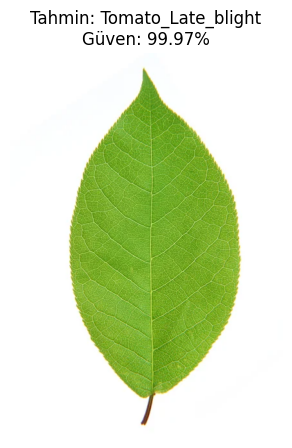

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step


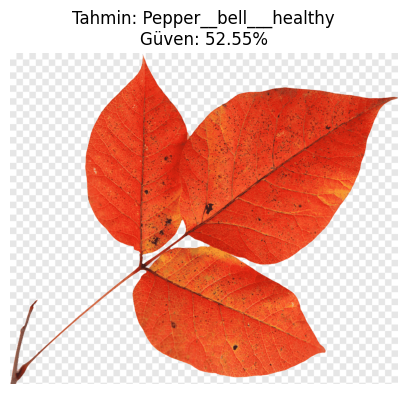

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step


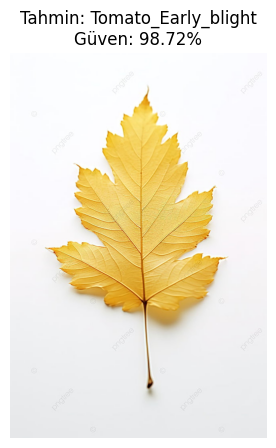

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step


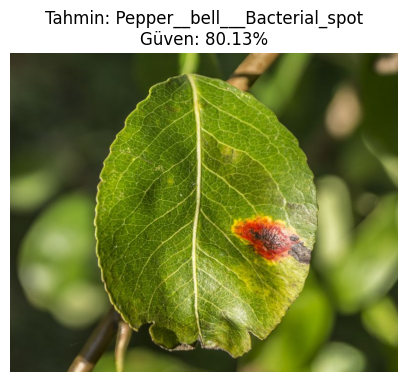

In [25]:
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt

for image_name in uploaded.keys():
    img = Image.open(image_name).convert("RGB")
    img_resized = img.resize((224, 224))

    img_array = np.array(img_resized)
    img_array = np.expand_dims(img_array, axis=0)

    prediction = model.predict(img_array)
    predicted_index = np.argmax(prediction)
    confidence = np.max(prediction)

    predicted_class = class_names[predicted_index]

    plt.figure(figsize=(5,5))
    plt.imshow(img)
    plt.axis("off")
    plt.title(f"Tahmin: {predicted_class}\nGüven: {confidence*100:.2f}%")
    plt.show()

In [26]:
from google.colab import files

files.download("AgroLeafNet_model.keras")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>